Device: cuda
Converted pheno_onehot to np.float32 for 0 nodes.
Feature/label tensors:
  x: (2409, 103)  y: (2409, 14)
  INPUT_DIMS: [103]
Loaded extra metadata: {'model': 'MOGSage', 'hidden_dim': 128, 'emb_dim': 64, 'seed': 7}
PyG data summary:
  num_nodes: 2409
  x shape:   (2409, 103) dtype=torch.float32
  y shape:   (2409, 14) dtype=torch.float32
  edges:     19022
NeighborLoader config:
  batch_size:    512
  num_neighbors: [15, 10]
  shuffle:       False
  num_workers:   0
  pin_memory:    True
Targets: (2409, 4) using column 1 -> (2409,)


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 2409 equal to the number of examples.
  warnings.warn(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:62: UserWarning: This method computes finite differences between evaluations at consecutive steps, so internal batch size must be at least twice the number of examples. Defaulting to internal batch size of 4818 equal to twice the number of examples.
  warnings.warn(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 2408 equal to the number of examples.
  warnings.warn(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/captum

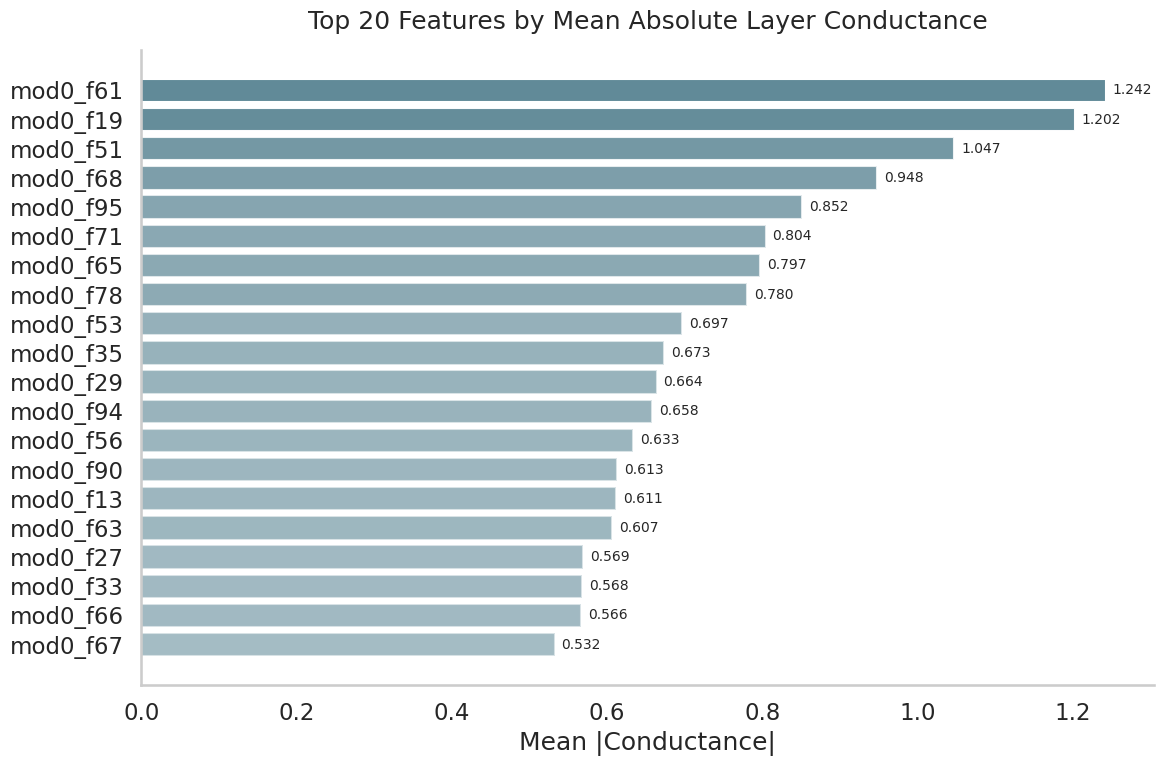

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Top 20 Features by Mean Absolute Layer Conductance'}, xlabel='Mean |Conductance|'>,
      Feature  Importance
 0   mod0_f67    0.532298
 1   mod0_f66    0.565993
 2   mod0_f33    0.568099
 3   mod0_f27    0.568983
 4   mod0_f63    0.606624
 5   mod0_f13    0.611454
 6   mod0_f90    0.612987
 7   mod0_f56    0.633031
 8   mod0_f94    0.658085
 9   mod0_f29    0.663736
 10  mod0_f35    0.672942
 11  mod0_f53    0.696557
 12  mod0_f78    0.780471
 13  mod0_f65    0.797346
 14  mod0_f71    0.804126
 15  mod0_f95    0.851572
 16  mod0_f68    0.947560
 17  mod0_f51    1.047241
 18  mod0_f19    1.202121
 19  mod0_f61    1.242142)

In [7]:
# ============================================================
# Identify Important Cluster Features
# ============================================================

import os, sys, pickle
from functools import reduce

import numpy as np
import pandas as pd
import torch

from torch_geometric.utils import from_networkx
from torch_geometric.loader import NeighborLoader

# ----------------------------
# Device
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ----------------------------
# Paths / imports from your project
# ----------------------------
sys.path.insert(0, "./../MAIN/")

from gnn import MOGSage
from helpers import load_pytorch_model, merge_dfs
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels
from applications import visualise_feature_importance

# ============================================================
# CONFIG
# ============================================================
DATADIR       = "/work/gr-fe/bryan/data/YEAST/"
GPREFIX       = "KGene"
ATTRS_TO_KEEP = {"pheno_onehot"}
SEED          = 7

# Model
ENC_DIMS     = [64]
LATENT_DIMS  = [32]
DECODER_DIM  = 32
GNN_DIMS     = [128, 64]
DROPOUT      = 0.2
LR           = 1e-3
CHECKPOINT   = "/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_model.pth"

# Loader / importance
BATCH_SIZE      = 512
NUM_NEIGHBORS   = [15, 10]
SHUFFLE         = False
NUM_WORKERS     = 0   # best for notebooks
PIN_MEMORY      = (device == "cuda")
PERSIST_WORKERS = False

TARGET_PATH = "/work/gr-fe/bryan/data/YEAST/03_final/yeast_cluster_membership.npy"
TARGET_COL  = 1

TOP_N       = 20
PLOT_TITLE  = "Top 20 Features by Mean Absolute Layer Conductance"

# ----------------------------
# Reproducibility (optional; keep if your pipeline is stochastic)
# ----------------------------
torch.manual_seed(SEED)
np.random.seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 1) LOAD GRAPH
# ============================================================
g = load_graph(os.path.join(DATADIR, "Networks", f"{GPREFIX}_psn.gpickle"), "PSN")
cnt = fix_pheno_onehot_in_graph(g)
print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

# Keep your original helpers (even if you don't use outputs later)
ei, order, weight = nx_to_pyg(g, ATTRS_TO_KEEP, get_weight=True)
all_nodes = sorted(set(g.nodes))

# ============================================================
# 2) LOAD FEATURES / LABELS
# ============================================================
expr_dfs = []
for expr in ["EXPR"]:
    with open(os.path.join(DATADIR, "02_processed", f"{expr}.processed.pkl"), "rb") as f:
        data_expr = pickle.load(f)
    expr_df = data_expr["expr"]
    expr_dfs.append(expr_df.loc[expr_df.index.intersection(all_nodes)].copy())

meta = node_labels(g)
meta = pd.DataFrame(np.float32(meta.values), index=meta.index)

h_df    = reduce(merge_dfs, expr_dfs).reindex(all_nodes)
meta_df = meta.reindex(all_nodes)

x = torch.tensor(h_df.values, dtype=torch.float32)
y = torch.tensor(meta_df.values, dtype=torch.float32)

INPUT_DIMS = [df.shape[1] for df in expr_dfs]

print("Feature/label tensors:")
print(f"  x: {tuple(x.shape)}  y: {tuple(y.shape)}")
print(f"  INPUT_DIMS: {INPUT_DIMS}")

# ============================================================
# 3) BUILD MODEL + LOAD CHECKPOINT
# ============================================================
model = MOGSage(
    input_dims=INPUT_DIMS,
    encoder_dims=ENC_DIMS,
    latent_dims=LATENT_DIMS,
    decoder_dim=DECODER_DIM,
    hidden_dims=GNN_DIMS,
    num_classes=y.shape[1],
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model, optimizer, extra, checkpoint = load_pytorch_model(
    model=model,
    model_path=CHECKPOINT,
    optimizer=optimizer,
    map_location=device,
)

model.eval()
print("Loaded extra metadata:", extra)

# ============================================================
# 4) PyG DATA + LOADER
# ============================================================
data = from_networkx(g)
data.x = x.float()
data.y = y.float()

print("PyG data summary:")
print(f"  num_nodes: {data.num_nodes}")
print(f"  x shape:   {tuple(data.x.shape)} dtype={data.x.dtype}")
print(f"  y shape:   {tuple(data.y.shape)} dtype={data.y.dtype}")
if hasattr(data, "edge_index"):
    print(f"  edges:     {data.edge_index.size(1)}")

loader = NeighborLoader(
    data,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_neighbors=NUM_NEIGHBORS,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSIST_WORKERS,
)

print("NeighborLoader config:")
print(f"  batch_size:    {BATCH_SIZE}")
print(f"  num_neighbors: {NUM_NEIGHBORS}")
print(f"  shuffle:       {SHUFFLE}")
print(f"  num_workers:   {NUM_WORKERS}")
print(f"  pin_memory:    {PIN_MEMORY}")

# ============================================================
# 5) TARGET CLASSES + FEATURE IMPORTANCE
# ============================================================
target_classes = np.load(TARGET_PATH)

if target_classes.shape[0] != data.num_nodes:
    raise ValueError(
        f"target_classes has {target_classes.shape[0]} rows, but data has {data.num_nodes} nodes. "
        "This usually indicates node-order mismatch between your saved targets and PyG node ordering."
    )

target_classes = torch.tensor(target_classes, dtype=torch.float32)
if TARGET_COL >= target_classes.shape[1]:
    raise IndexError(
        f"TARGET_COL={TARGET_COL} out of bounds for target_classes with {target_classes.shape[1]} columns."
    )

target_vec = target_classes[:, TARGET_COL]
print(f"Targets: {tuple(target_classes.shape)} using column {TARGET_COL} -> {tuple(target_vec.shape)}")

with torch.no_grad():
    importances = model.feature_importance(
        loader=loader,
        device=device,
        target_classes=target_vec,
    )

# Optional: attach names if returned as a DataFrame (depends on your implementation)
# if isinstance(importances, pd.DataFrame):
#     importances.columns = h_df.columns

# ============================================================
# 6) VISUALISE
# ============================================================
fig, _, df_plot = visualise_feature_importance(
    importances,
    top_n=TOP_N,
    title=PLOT_TITLE,
)
